In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import matplotlib.pyplot as plt
from collections import Counter

Дифференциация по классам: Миноритарные классы получают более агрессивные аугментации

Балансировка батчей: Использование WeightedRandomSampler для балансировки

In [2]:
class ImbalancedCIFAR10(Dataset):
    def __init__(self, original_dataset, class_ratios=None, train=True):
        """
        class_ratios: словарь с соотношениями для каждого класса
        Например: {0: 1.0, 1: 0.1, 2: 0.05, ...} - класс 0 все примеры, класс 1 - 10%, и т.д.
        """
        self.data = []
        self.targets = []

        if class_ratios is None:
            # Пример сильного дисбаланса
            class_ratios = {
                0: 1.0,   # airplane - все примеры
                1: 0.1,   # automobile - 10%
                2: 0.05,  # bird - 5%
                3: 0.02,  # cat - 2%
                4: 0.01,  # deer - 1%
                5: 0.5,   # dog - 50%
                6: 0.3,   # frog - 30%
                7: 0.8,   # horse - 80%
                8: 0.15,  # ship - 15%
                9: 0.25   # truck - 25%
            }

        # Собираем данные по классам
        class_data = {i: [] for i in range(10)}
        class_targets = {i: [] for i in range(10)}

        for img, target in original_dataset:
            class_data[target].append(img)
            class_targets[target].append(target)

        # Применяем соотношения
        for class_idx in range(10):
            n_samples = len(class_data[class_idx])
            n_select = int(n_samples * class_ratios[class_idx])

            indices = np.random.choice(n_samples, n_select, replace=False)

            self.data.extend([class_data[class_idx][i] for i in indices])
            self.targets.extend([class_targets[class_idx][i] for i in indices])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx]

In [3]:
class DifferentialAugmentation:
    """Разные аугментации для разных классов"""

    @staticmethod
    def get_minority_transforms():
        """Сильная аугментация для миноритарных классов"""
        return transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
            transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),
            transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
        ])

    @staticmethod
    def get_majority_transforms():
        """Слабая аугментация для мажоритарных классов"""
        return transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.3),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
        ])

    @staticmethod
    def get_validation_transforms():
        """Трансформации для валидации (без аугментации)"""
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
        ])

In [4]:
class DifferentiallyAugmentedDataset(Dataset):
    """Датасет, применяющий разные аугментации к разным классам"""

    def __init__(self, dataset, minority_classes, majority_classes):
        """
        dataset: исходный датасет
        minority_classes: список миноритарных классов
        majority_classes: список мажоритарных классов
        """
        self.dataset = dataset
        self.minority_classes = set(minority_classes)
        self.majority_classes = set(majority_classes)

        # Создаем трансформации
        self.minority_transform = DifferentialAugmentation.get_minority_transforms()
        self.majority_transform = DifferentialAugmentation.get_majority_transforms()

        # Предварительно разделяем индексы по классам для быстрого доступа
        self.minority_indices = []
        self.majority_indices = []

        for idx, (_, label) in enumerate(dataset):
            if label in self.minority_classes:
                self.minority_indices.append(idx)
            else:
                self.majority_indices.append(idx)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        # Применяем соответствующую трансформацию
        if label in self.minority_classes:
            img = self.minority_transform(img)
        else:
            img = self.majority_transform(img)

        return img, label

Распределение классов в несбалансированном датасете:
Класс 0: 5000 примеров
Класс 1: 500 примеров
Класс 2: 250 примеров
Класс 3: 100 примеров
Класс 4: 50 примеров
Класс 5: 2500 примеров
Класс 6: 1500 примеров
Класс 7: 4000 примеров
Класс 8: 750 примеров
Класс 9: 1250 примеров

Миноритарные классы: [1, 2, 3, 4, 8]
Мажоритарные классы: [0, 5, 6, 7, 9]


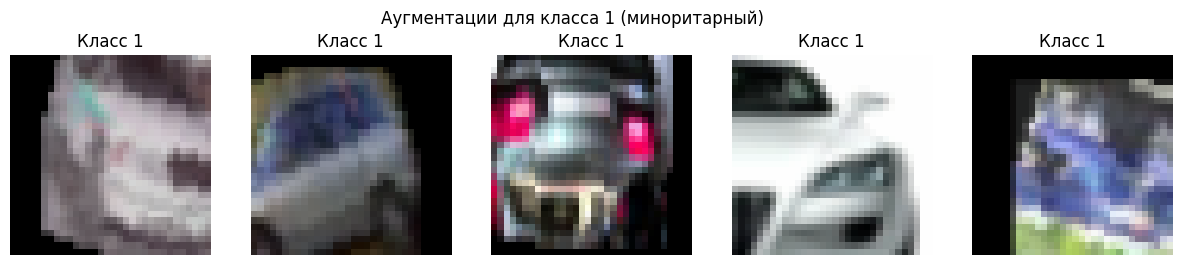

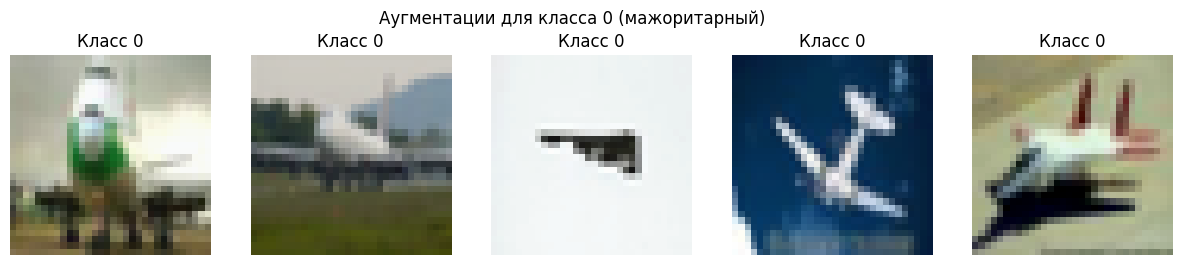

In [5]:
def main():
    # Загрузка CIFAR-10
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    # Загружаем оригинальный CIFAR-10
    train_dataset_full = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=None
    )

    # Создаем несбалансированную версию
    imbalanced_dataset = ImbalancedCIFAR10(train_dataset_full)

    # Анализируем дисбаланс
    class_counts = Counter(imbalanced_dataset.targets)
    print("Распределение классов в несбалансированном датасете:")
    for class_idx in range(10):
        print(f"Класс {class_idx}: {class_counts[class_idx]} примеров")

    # Определяем миноритарные и мажоритарные классы
    total_samples = len(imbalanced_dataset)
    minority_threshold = total_samples / 20  # 5% от общего количества

    minority_classes = []
    majority_classes = []

    for class_idx in range(10):
        if class_counts[class_idx] < minority_threshold:
            minority_classes.append(class_idx)
        else:
            majority_classes.append(class_idx)

    print(f"\nМиноритарные классы: {minority_classes}")
    print(f"Мажоритарные классы: {majority_classes}")

    # Создаем датасет с дифференцированной аугментацией
    diff_aug_dataset = DifferentiallyAugmentedDataset(
        imbalanced_dataset, minority_classes, majority_classes
    )

    # Создаем WeightedRandomSampler для балансировки батчей
    class_weights = []
    for target in imbalanced_dataset.targets:
        class_weights.append(1.0 / class_counts[target])

    sampler = WeightedRandomSampler(
        weights=class_weights,
        num_samples=len(imbalanced_dataset),
        replacement=True
    )

    # WeightedRandomSampler — инструмент в библиотеке PyTorch,
    # который позволяет выбирать образцы для обучения модели,
    # основываясь на предварительно заданных весах.

    # DataLoader с семплером
    batch_size = 64
    train_loader = DataLoader(
        diff_aug_dataset,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=2
    )

    # Для валидации используем обычный CIFAR-10
    val_transform = DifferentialAugmentation.get_validation_transforms()
    val_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=val_transform
    )
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # Пример: визуализация аугментированных изображений
    def visualize_augmentations(dataset, class_to_visualize=3, n_samples=5):
        """Визуализируем аугментации для конкретного класса"""
        fig, axes = plt.subplots(1, n_samples, figsize=(15, 3))

        indices = [i for i, (_, label) in enumerate(dataset.dataset)
                  if label == class_to_visualize][:n_samples]

        for i, idx in enumerate(indices):
            img, label = dataset[idx]
            # Денормализуем для отображения
            img = img.numpy().transpose((1, 2, 0))
            mean = np.array([0.4914, 0.4822, 0.4465])
            std = np.array([0.2023, 0.1994, 0.2010])
            img = std * img + mean
            img = np.clip(img, 0, 1)

            axes[i].imshow(img)
            axes[i].set_title(f'Класс {label}')
            axes[i].axis('off')

        plt.suptitle(f'Аугментации для класса {class_to_visualize} '
                    f'({"миноритарный" if class_to_visualize in minority_classes else "мажоритарный"})')
        plt.show()

    # Визуализируем для миноритарного и мажоритарного классов
    if len(minority_classes) > 0:
        visualize_augmentations(diff_aug_dataset, minority_classes[0], 5)
    if len(majority_classes) > 0:
        visualize_augmentations(diff_aug_dataset, majority_classes[0], 5)

    return train_loader, val_loader, class_counts

if __name__ == "__main__":
    train_loader, val_loader, class_counts = main()